In [2]:
!pip install yfinance arch tensorflow scikit-learn scipy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.3 MB/s eta 0:00:00


In [3]:
# ── CELL 2: Imports ───────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import yfinance as yf
from arch import arch_model
from scipy import stats

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [4]:
# ── CELL 3: Data Acquisition & Cleaning ───────────────────────
print("\n[Step 1] Downloading BTC-USD data from 2020-01-01 to 2026-01-01...")

raw = yf.download('BTC-USD', start='2020-01-01', end='2026-01-01', auto_adjust=True)

# yfinance sometimes returns a MultiIndex — flatten it
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

df = raw[['Close']].copy()

# Daily log returns (%) — preferred in financial research over simple returns
df['Returns'] = 100 * np.log(df['Close'] / df['Close'].shift(1))

# Realized Volatility: 30-day rolling std of returns
# This is our "ground truth" / target variable for both models
df['Realized_Vol'] = df['Returns'].rolling(window=30).std()

# Drop NaNs introduced by rolling window and log return
df.dropna(inplace=True)

print(f"Clean dataset: {len(df)} trading days")
print(df.tail())



[Step 1] Downloading BTC-USD data from 2020-01-01 to 2026-01-01...


[*********************100%***********************]  1 of 1 completed

Clean dataset: 2162 trading days
Price              Close   Returns  Realized_Vol
Date                                            
2025-12-27  87802.156250  0.571922      1.965902
2025-12-28  87835.835938  0.038351      1.965443
2025-12-29  87138.140625 -0.797489      1.969358
2025-12-30  88430.132812  1.471810      1.989662
2025-12-31  87508.828125 -1.047310      1.807509


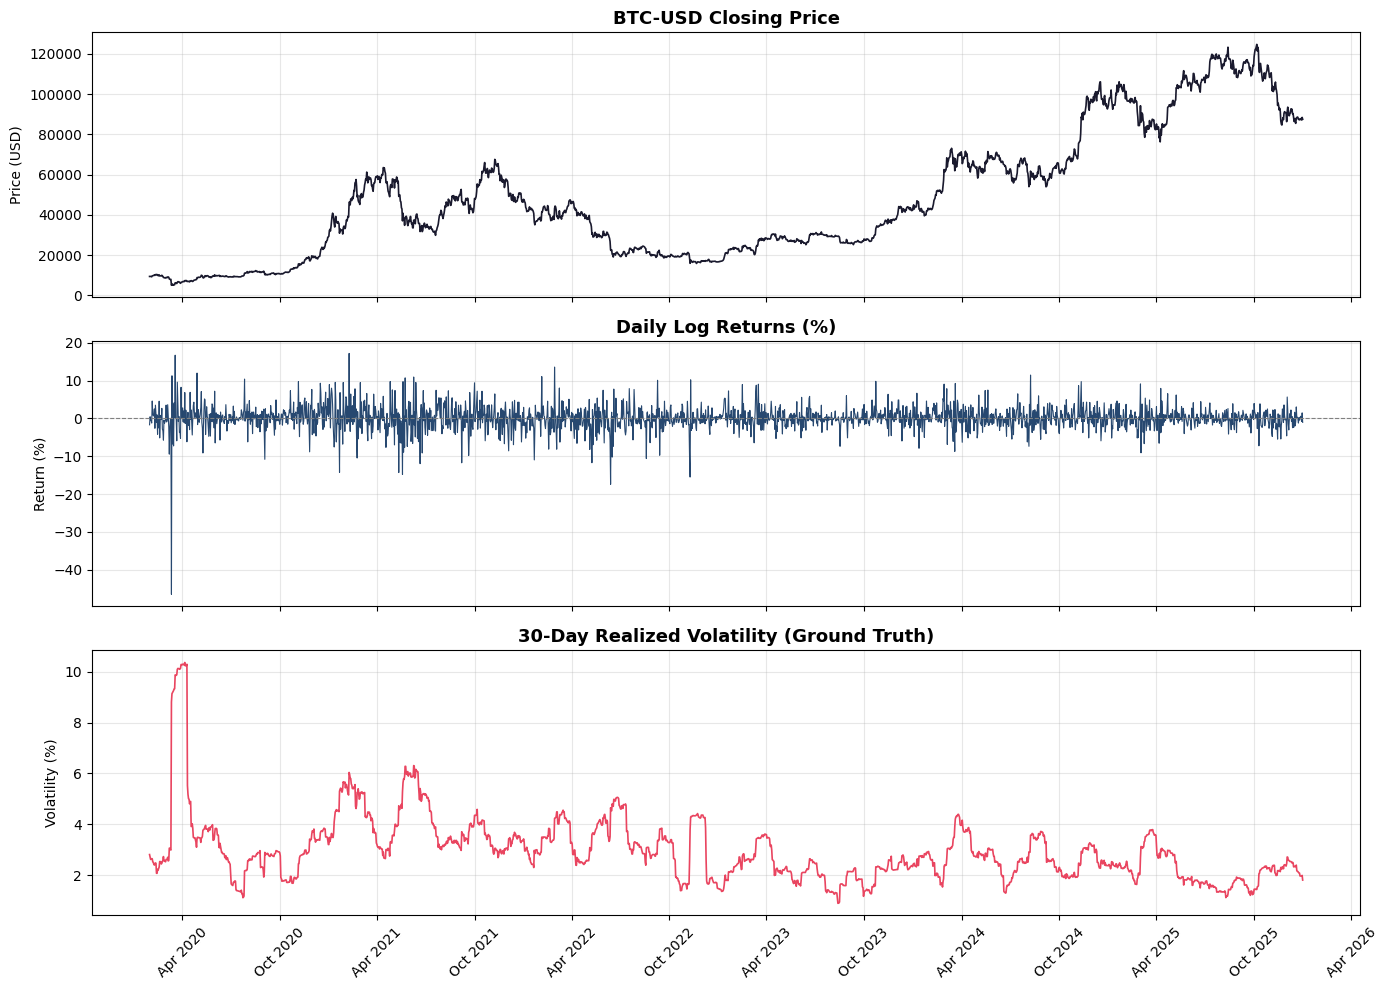

EDA plot saved.


In [5]:
# ── CELL 4: EDA — Price & Returns Overview ────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, df['Close'], color='#1a1a2e', linewidth=1.2)
axes[0].set_title('BTC-USD Closing Price', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].grid(alpha=0.3)

axes[1].plot(df.index, df['Returns'], color='#0f3460', linewidth=0.8, alpha=0.9)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title('Daily Log Returns (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Return (%)')
axes[1].grid(alpha=0.3)

axes[2].plot(df.index, df['Realized_Vol'], color='#e94560', linewidth=1.2)
axes[2].set_title('30-Day Realized Volatility (Ground Truth)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Volatility (%)')
axes[2].grid(alpha=0.3)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plot saved.")


[Step 2] Fitting GARCH(1,1) model...
                           Constant Mean - GARCH Model Results                           
Dep. Variable:                           Returns   R-squared:                       0.000
Mean Model:                        Constant Mean   Adj. R-squared:                  0.000
Vol Model:                                 GARCH   Log-Likelihood:               -5219.86
Distribution:      Standardized Skew Student's t   AIC:                           10451.7
Method:                       Maximum Likelihood   BIC:                           10485.8
                                                   No. Observations:                 2162
Date:                           Wed, Apr 15 2026   Df Residuals:                     2161
Time:                                   11:20:35   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.


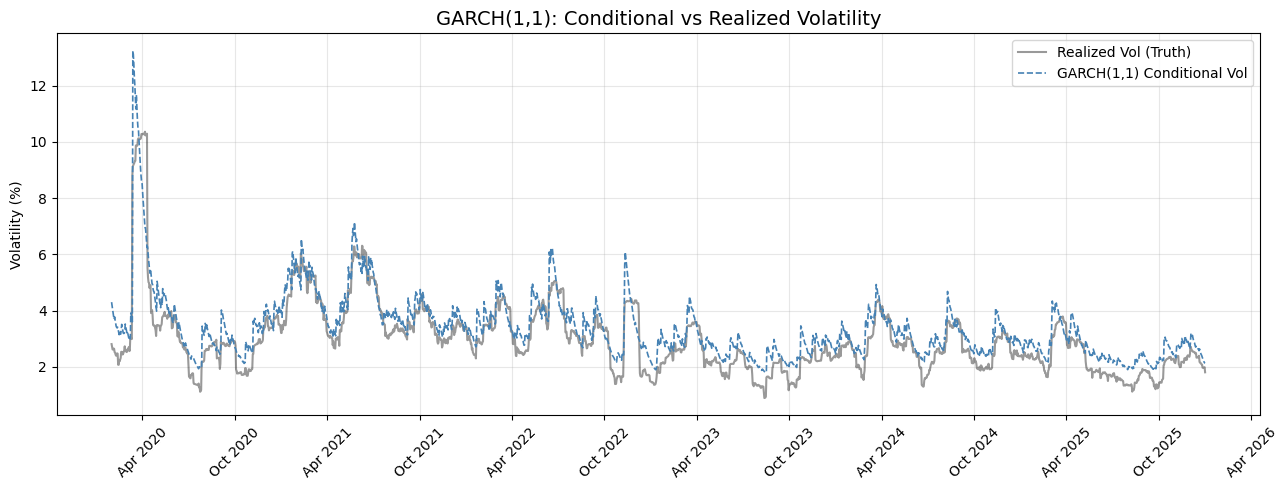

In [6]:
# ── CELL 5: MODEL 1 — GARCH(1,1) ─────────────────────────────
print("\n[Step 2] Fitting GARCH(1,1) model...")

am = arch_model(
    df['Returns'],
    vol='Garch',
    p=1, q=1,
    dist='skewt'        # Skewed-t is standard for financial returns
)
garch_res = am.fit(disp='off', show_warning=False)

print(garch_res.summary())

# GARCH conditional volatility (annualised → keep as daily %)
df['GARCH_Vol'] = garch_res.conditional_volatility

# Quick GARCH-only plot
plt.figure(figsize=(13, 5))
plt.plot(df.index, df['Realized_Vol'], label='Realized Vol (Truth)',
         color='black', alpha=0.4, linewidth=1.5)
plt.plot(df.index, df['GARCH_Vol'], label='GARCH(1,1) Conditional Vol',
         color='steelblue', linewidth=1.2, linestyle='--')
plt.title('GARCH(1,1): Conditional vs Realized Volatility', fontsize=14)
plt.ylabel('Volatility (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('garch_output.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
# ── CELL 6: MODEL 2 — LSTM (Predicts Realized Volatility) ─────
print("\n[Step 3] Preparing LSTM...")

# KEY FIX: Scale REALIZED VOLATILITY (not raw returns) as the target.
# Both X (features) and y (target) are derived from Realized_Vol
# so we're training the LSTM to forecast the same quantity as GARCH.

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_vol = scaler.fit_transform(df['Realized_Vol'].values.reshape(-1, 1))

LOOKBACK = 30   # Use 30 days of past volatility to predict next day

X, y = [], []
for i in range(LOOKBACK, len(scaled_vol)):
    X.append(scaled_vol[i - LOOKBACK:i, 0])
    y.append(scaled_vol[i, 0])

X = np.array(X).reshape(-1, LOOKBACK, 1)
y = np.array(y)

# ── 80/20 Train-Test Split (NO data leakage) ──────────────────
split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Corresponding dates for the test set
# The first usable date is at index LOOKBACK in df
all_dates = df.index[LOOKBACK:]
test_dates = all_dates[split:]

print(f"Train samples : {len(X_train)}")
print(f"Test  samples : {len(X_test)}")
print(f"Test date range: {test_dates[0].date()} → {test_dates[-1].date()}")


[Step 3] Preparing LSTM...
Train samples : 1705
Test  samples : 427
Test date range: 2024-10-31 → 2025-12-31



[Step 4] Training LSTM...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 14s 94ms/step - loss: 0.0095 - val_loss: 0.0015
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0046 - val_loss: 8.1441e-04
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0039 - val_loss: 8.7362e-04
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0036 - val_loss: 0.0018
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0036 - val_loss: 0.0011
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0033 - val_loss: 0.0016
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0033 - val_loss: 0.0013


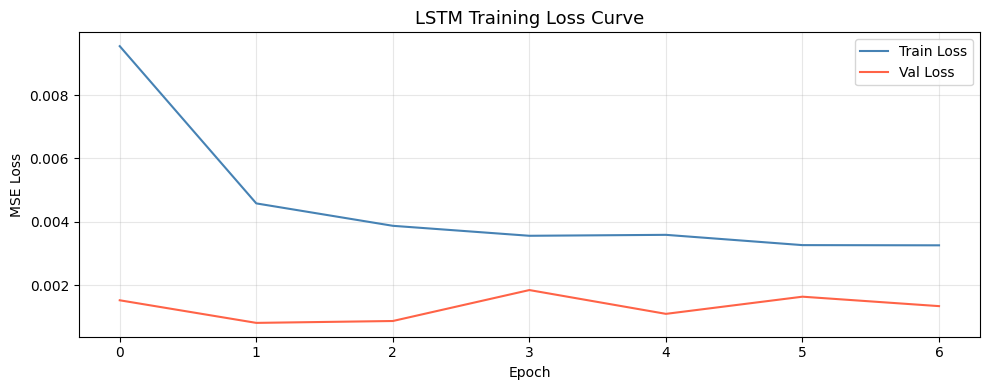

In [8]:
# ── CELL 7: Build & Train LSTM ────────────────────────────────
print("\n[Step 4] Training LSTM...")

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.10,   # 10% of training set for validation
    callbacks=[early_stop],
    verbose=1
)

# Training Loss Curve
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss', color='steelblue')
plt.plot(history.history['val_loss'], label='Val Loss', color='tomato')
plt.title('LSTM Training Loss Curve', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ── CELL 8: Predictions & Rescaling ──────────────────────────
lstm_pred_scaled = model.predict(X_test)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).flatten()
actual_vol = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# GARCH test-period values aligned to the same test dates
garch_test = df.loc[test_dates, 'GARCH_Vol'].values

print(f"\nShapes — Actual: {actual_vol.shape}, LSTM: {lstm_pred.shape}, GARCH: {garch_test.shape}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step

Shapes — Actual: (427,), LSTM: (427,), GARCH: (427,)


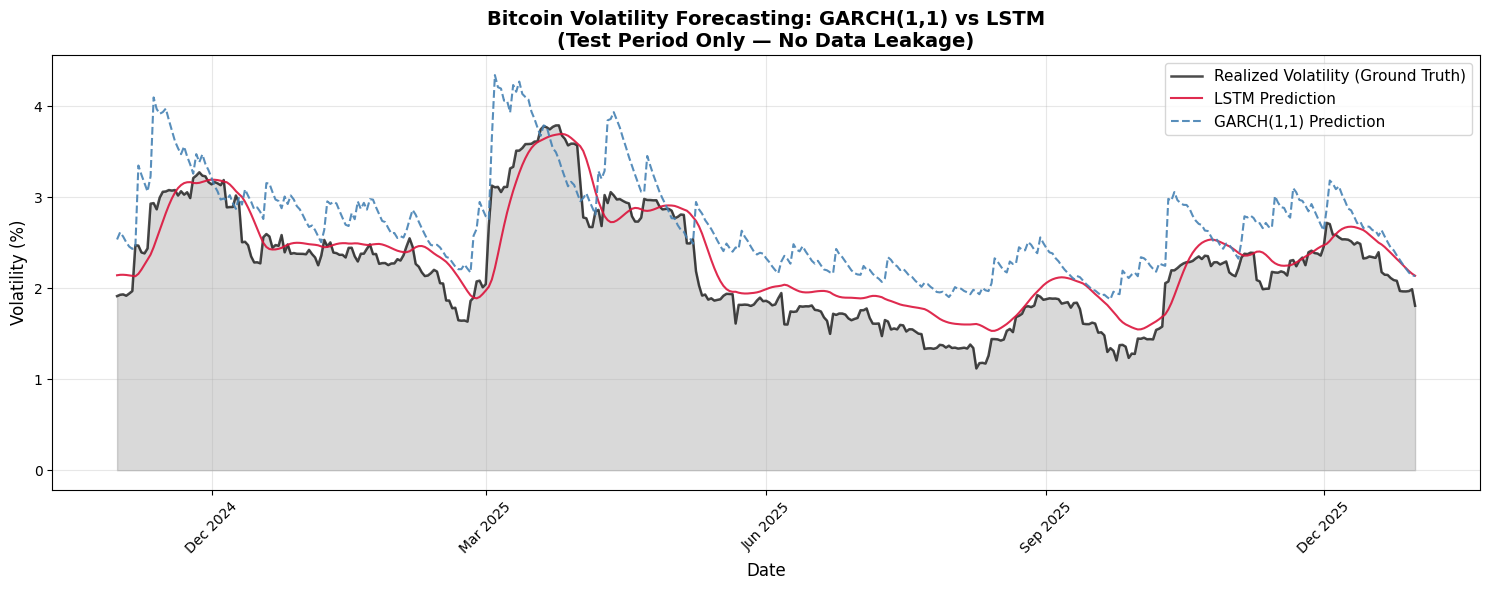

Main comparison plot saved.


In [10]:
# ── CELL 9: Main Comparison Plot ──────────────────────────────
fig, ax = plt.subplots(figsize=(15, 6))

ax.fill_between(test_dates, actual_vol, alpha=0.15, color='black')
ax.plot(test_dates, actual_vol,
        label='Realized Volatility (Ground Truth)',
        color='black', linewidth=1.8, alpha=0.7)
ax.plot(test_dates, lstm_pred,
        label='LSTM Prediction',
        color='crimson', linewidth=1.5, alpha=0.9)
ax.plot(test_dates, garch_test,
        label='GARCH(1,1) Prediction',
        color='steelblue', linewidth=1.5, linestyle='--', alpha=0.9)

ax.set_title('Bitcoin Volatility Forecasting: GARCH(1,1) vs LSTM\n(Test Period Only — No Data Leakage)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Volatility (%)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('volatility_comparison_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Main comparison plot saved.")

In [11]:
# ── CELL 10: Performance Metrics ─────────────────────────────
mae_garch  = mean_absolute_error(actual_vol, garch_test)
mae_lstm   = mean_absolute_error(actual_vol, lstm_pred)
rmse_garch = np.sqrt(mean_squared_error(actual_vol, garch_test))
rmse_lstm  = np.sqrt(mean_squared_error(actual_vol, lstm_pred))

# MAPE (watch out for zeros in denominator — shouldn't occur here)
mape_garch = np.mean(np.abs((actual_vol - garch_test) / actual_vol)) * 100
mape_lstm  = np.mean(np.abs((actual_vol - lstm_pred)  / actual_vol)) * 100

print("\n" + "="*45)
print("        PERFORMANCE SUMMARY (Test Set)")
print("="*45)
print(f"{'Metric':<12} {'GARCH(1,1)':>12} {'LSTM':>12}")
print("-"*45)
print(f"{'MAE':<12} {mae_garch:>12.4f} {mae_lstm:>12.4f}")
print(f"{'RMSE':<12} {rmse_garch:>12.4f} {rmse_lstm:>12.4f}")
print(f"{'MAPE (%)':<12} {mape_garch:>12.2f} {mape_lstm:>12.2f}")
print("="*45)

winner = "LSTM" if mae_lstm < mae_garch else "GARCH(1,1)"
print(f"\n➜  Lower MAE winner: {winner}")


        PERFORMANCE SUMMARY (Test Set)
Metric         GARCH(1,1)         LSTM
---------------------------------------------
MAE                0.4986       0.2061
RMSE               0.5488       0.2546
MAPE (%)            25.34        10.51

➜  Lower MAE winner: LSTM



--- RESIDUAL ANALYSIS ---
GARCH → Mean: -0.4740,  Std: 0.2766
LSTM  → Mean: -0.1245,  Std: 0.2220


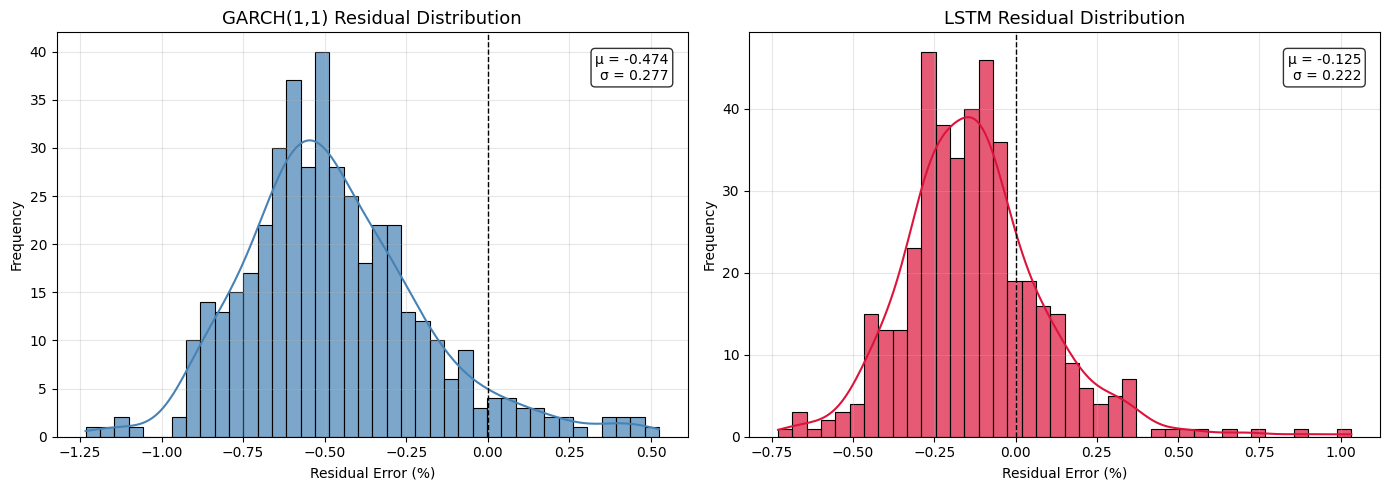

In [12]:
# ── CELL 11: Residual Analysis ────────────────────────────────
garch_residuals = actual_vol - garch_test
lstm_residuals  = actual_vol - lstm_pred

print("\n--- RESIDUAL ANALYSIS ---")
print(f"GARCH → Mean: {np.mean(garch_residuals):.4f},  Std: {np.std(garch_residuals):.4f}")
print(f"LSTM  → Mean: {np.mean(lstm_residuals):.4f},  Std: {np.std(lstm_residuals):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, residuals, label, color in zip(
        axes,
        [garch_residuals, lstm_residuals],
        ['GARCH(1,1)', 'LSTM'],
        ['steelblue', 'crimson']):

    sns.histplot(residuals, kde=True, color=color, bins=40, ax=ax, alpha=0.7)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{label} Residual Distribution', fontsize=13)
    ax.set_xlabel('Residual Error (%)')
    ax.set_ylabel('Frequency')
    ax.grid(alpha=0.3)

    mean_r = np.mean(residuals)
    std_r  = np.std(residuals)
    ax.text(0.97, 0.95, f'μ = {mean_r:.3f}\nσ = {std_r:.3f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('residual_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ── CELL 12: Diebold-Mariano Test ────────────────────────────
def diebold_mariano_test(y_true, y_pred1, y_pred2, h=1, power=2):
    """
    Tests whether two forecasts have statistically different accuracy.
    H0: No difference in forecast accuracy.
    y_pred1 = LSTM, y_pred2 = GARCH
    Negative DM stat → pred1 (LSTM) is more accurate.
    """
    e1 = y_true - y_pred1
    e2 = y_true - y_pred2
    d  = np.abs(e1)**power - np.abs(e2)**power

    T      = len(d)
    mean_d = np.mean(d)

    # Newey-West variance (accounts for autocorrelation up to lag h-1)
    var_d = np.var(d, ddof=1)
    if h > 1:
        for lag in range(1, h):
            cov = np.cov(d[lag:], d[:-lag], bias=True)[0, 1]
            var_d += 2 * cov

    DM_stat = mean_d / np.sqrt(var_d / T)
    p_value = 2 * (1 - stats.norm.cdf(abs(DM_stat)))

    return DM_stat, p_value


dm_stat, p_value = diebold_mariano_test(actual_vol, lstm_pred, garch_test, h=1, power=2)

print("\n" + "="*45)
print("       DIEBOLD-MARIANO TEST (MSE-based)")
print("="*45)
print(f"DM Statistic : {dm_stat:.4f}")
print(f"P-value      : {p_value:.6f}")
alpha = 0.05
if p_value < alpha:
    print(f"\nResult (α={alpha}): Statistically SIGNIFICANT difference.")
    direction = "LSTM" if dm_stat < 0 else "GARCH(1,1)"
    print(f"➜ {direction} produces significantly more accurate forecasts.")
else:
    print(f"\nResult (α={alpha}): No statistically significant difference.")
    print("➜ Neither model is statistically superior.")
print("="*45)


       DIEBOLD-MARIANO TEST (MSE-based)
DM Statistic : -20.9425
P-value      : 0.000000

Result (α=0.05): Statistically SIGNIFICANT difference.
➜ LSTM produces significantly more accurate forecasts.


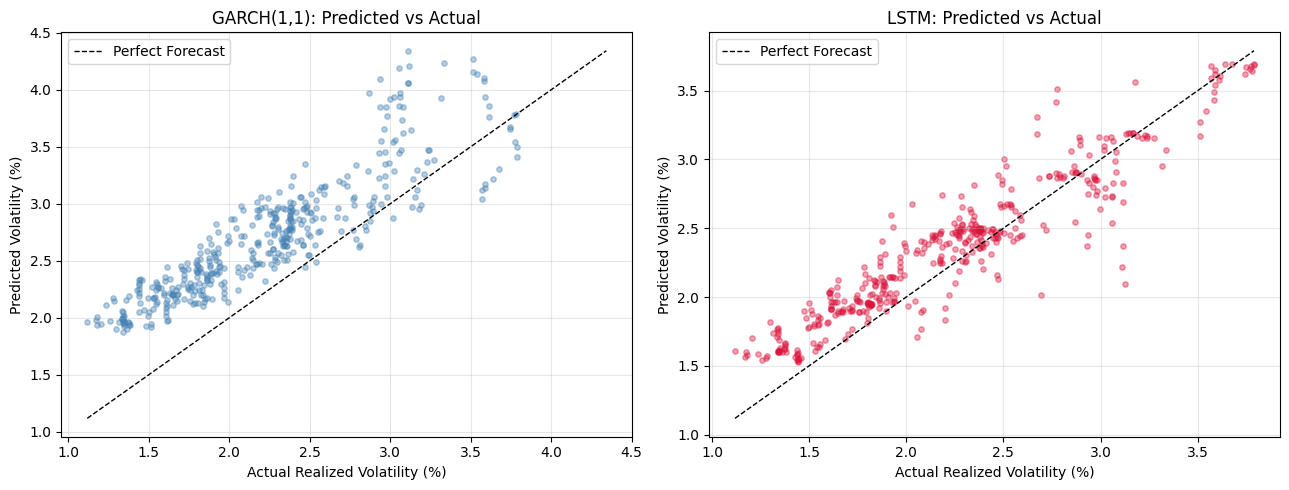


✓ All cells complete. Figures saved.


In [14]:
# ── CELL 13: Scatter Plot (Predicted vs Actual) ───────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, pred, label, color in zip(
        axes,
        [garch_test, lstm_pred],
        ['GARCH(1,1)', 'LSTM'],
        ['steelblue', 'crimson']):

    ax.scatter(actual_vol, pred, alpha=0.4, s=15, color=color)
    lims = [min(actual_vol.min(), pred.min()), max(actual_vol.max(), pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect Forecast')
    ax.set_title(f'{label}: Predicted vs Actual', fontsize=12)
    ax.set_xlabel('Actual Realized Volatility (%)')
    ax.set_ylabel('Predicted Volatility (%)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('scatter_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ All cells complete. Figures saved.")

In [15]:
from statsmodels.tsa.stattools import adfuller

# Run ADF test on the Returns column
# (Log-transformation + Differencing usually makes it stationary)
print("--- ADF Test on BTC Log Returns ---")
adf_result = adfuller(df['Returns'].dropna())

print(f'ADF Statistic: {adf_result[0]:.4f}')
print(f'p-value: {adf_result[1]:.4f}')

# Critical values for comparison
for key, value in adf_result[4].items():
    print(f'Critical Value ({key}): {value:.4f}')

if adf_result[1] <= 0.05:
    print("\nRESULT: The series is STATIONARY. You can safely use GARCH and LSTM.")
else:
    print("\nRESULT: The series is NON-STATIONARY. Your models may produce unreliable results.")

--- ADF Test on BTC Log Returns ---
ADF Statistic: -15.2223
p-value: 0.0000
Critical Value (1%): -3.4334
Critical Value (5%): -2.8629
Critical Value (10%): -2.5675

RESULT: The series is STATIONARY. You can safely use GARCH and LSTM.
